# Installation and configuration of IBL packages

In [24]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pickle
from pathlib import Path

#all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")

In [25]:
import pickle

with open("notebook_outputs/q3_workspace.pkl", "rb") as f:
    globals().update(pickle.load(f))

# Q4. Is mouse behavior stationary?

`Stationary` means the mouse uses the same strategy through the whole session.

`Non-stationary` means the mouse changes strategy during the session.

In the updated Q3 model, the behavioral-history model is not only:

```text
choice ~ signed_contrast + previous_choice + previous_reward
```

Now Q3 also includes the interaction:

```text
previous_choice x previous_reward
```

So in Q4, the stationarity question becomes:

```text
Do the updated Q3 interaction-model parameters stay stable within one session?
```

Q4 tests whether these parameters change over sliding windows:

- bias
- signed contrast weight
- previous choice weight
- previous reward weight
- previous_choice x previous_reward interaction weight

If these coefficients change across windows, then behavior is non-stationary.


### Q4-1. Create a copy of updated Q3 interaction data

I do not change `df_q3_interaction` or old Q3 results.

For Q4, I make a new copy called `df_q4`.

Because Q3 changed, Q4 now uses the updated Q3 interaction model variables:

- `signed_contrast`
- `prev_choice_centered`
- `prev_reward_centered`
- `prev_choice_x_reward`
- `choice_binary`

This means Q4 tests whether the **interaction model parameters** are stationary within the session.


In [26]:
# Create Q4 copy. Do not change Q3 interaction data.
df_q4 = df_q3_interaction.copy(deep=True)

# Safety check: create centered history columns if they are missing.
if 'prev_choice_centered' not in df_q4.columns:
    df_q4['prev_choice_centered'] = df_q4['prev_choice_binary'].astype(float) * 2 - 1

if 'prev_reward_centered' not in df_q4.columns:
    df_q4['prev_reward_centered'] = df_q4['prev_rewarded'].astype(float) * 2 - 1

if 'prev_choice_x_reward' not in df_q4.columns:
    df_q4['prev_choice_x_reward'] = (
        df_q4['prev_choice_centered']
        * df_q4['prev_reward_centered']
    )

q4_feature_columns = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]

# Sort trials in time order inside session.
sort_columns_q4 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q4.columns
]
df_q4 = df_q4.sort_values(sort_columns_q4).copy(deep=True)

display(
    df_q4[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded',
        'prev_choice_centered',
        'prev_reward_centered',
        'prev_choice_x_reward'
    ]].head()
)

print('Q4 rows:', len(df_q4))
print('Q4 stationarity features:', q4_feature_columns)


,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0,1.0,-1.0,-1.0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1,1.0,1.0,1.0
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0,1.0,-1.0,-1.0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0,1.0,-1.0,-1.0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1,-1.0,1.0,-1.0


Q4 rows: 2129698
Q4 stationarity features: ['signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward']


### Q4-2. We need one session for sliding-window analysis.

Requirements:

1. enough trials  
2. both choices: `0` and `1`    #q4_session_summary
3. largest valid session #at least 200 trials

- choose 1 session with enough trials

- Instead of 1 model for the whole session, we cut it into sliding windows like 150-200 trials each, shifting by 50 trials at a time.

- Refit the updated Q3 interaction model in each window:

```text
choice ~ signed_contrast
       + previous_choice
       + previous_reward
       + previous_choice x previous_reward
```

- Track how the coefficients change from window to window.

- Compare the parameters across time with a Cochran-style heterogeneity test.

If the parameters change a lot within the session, then behavior may be **non-stationary**.


write why scipy not skilearn linear regression?

In [27]:
import statsmodels.api as sm
from scipy import stats

In [28]:
# ШАГ 1. Lets settings sliding-window
# WINDOW_SIZE = how many trials go into one window.
# STEP = how far the window moves each time.
# PARAM_NAMES = model parameters we will track over time.
WINDOW_SIZE = 200
STEP = 50
PARAM_NAMES = ['bias'] + q4_feature_columns

print('Q4 parameters tested for stationarity:')
print(PARAM_NAMES)


Q4 parameters tested for stationarity:
['bias', 'signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward']


In [29]:
# Шаг 2. This function fits the updated Q3 interaction logistic model inside 1 window.
# It returns coefficients and standard errors, because we need standard errors for the stationarity test.

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def fit_window_logistic(df_window):

    X = sm.add_constant(df_window[q4_feature_columns].values)
    y = df_window['choice_binary'].values

    if len(np.unique(y)) < 2:
        return None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            result = sm.Logit(y, X).fit(
                disp=0,
                maxiter=200
            )

        return result.params, result.bse

    except Exception:
        return None


# 3. Choose example mice and sessions.
# We take 2 best mice from the updated Q3 interaction model and choose the longest session for each.
# Long sessions are needed because sliding windows need enough trials.
if 'q3_interaction_results_df' in globals():
    example_mice = (
        q3_interaction_results_df
        .sort_values('log_likelihood_q3_interaction', ascending=False)['subject']
        .head(2)
    )
else:
    example_mice = (
        q3_results_df.sort_values('log_likelihood_q3', ascending=False)['subject'].head(2)
    )

example_sessions = {
    subject: df_q4.loc[df_q4['subject'] == subject, 'session'].value_counts().idxmax()
    for subject in example_mice
}

print('Example mice:', list(example_mice))
print('Example sessions:', example_sessions)


Example mice: ['ZM_1085', 'CSH_ZAD_007']
Example sessions: {'ZM_1085': '8c985920-2434-483f-a99e-d143e7921b32', 'CSH_ZAD_007': 'b48f015d-fe02-4298-9e62-3ea9780737f6'}


WINDOW_SIZE = 200
STEP = 50

window 1: trials 0-199

window 2: trials 50-249

window 3: trials 100-299

In [30]:
# 4. Fit Q3 model in sliding windows.
# Each window gives 1 set of parameters. If parameters change across windows, behavior may be non-stationary.
window_results = {}

for subject, session in example_sessions.items(): #For each selected mouse/session, split the session into sliding windows.

    df_sess = (
        df_q4[(df_q4['subject'] == subject) & (df_q4['session'] == session)]
        .sort_values('intervals_0')
        .reset_index(drop=True)
    )

    rows = []

    for start in range(0, len(df_sess) - WINDOW_SIZE + 1, STEP): #Move a sliding window through the session.

        window = df_sess.iloc[start:start + WINDOW_SIZE] #Take the trials inside the current window.
       
        fit = fit_window_logistic(window)   #Fit Q3 logistic regression on this window.

        if fit is None:
            continue

        params, se = fit
        row = {'window_center': start + WINDOW_SIZE // 2} #We save window_center because it tells us where this window is located in the session.

        for name, p, s in zip(PARAM_NAMES, params, se): #Match each parameter name with its estimate and standard error.
            row[f'{name}_est'] = p
            row[f'{name}_se'] = s

        rows.append(row)

    window_results[(subject, session)] = pd.DataFrame(rows)


/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [31]:
# Combine all window result tables into one table
window_results_table = []

for (subject, session), df_win in window_results.items():
    df_temp = df_win.copy()
    df_temp['subject'] = subject
    df_temp['session'] = session
    window_results_table.append(df_temp)

window_results_table = pd.concat(window_results_table, ignore_index=True)

display(window_results_table.head())

,window_center,bias_est,bias_se,signed_contrast_est,signed_contrast_se,prev_choice_centered_est,prev_choice_centered_se,prev_reward_centered_est,prev_reward_centered_se,prev_choice_x_reward_est,prev_choice_x_reward_se,subject,session
0,100,0.663679,0.979617,40.680859,8.702796,-0.528598,0.975669,-0.585847,0.977905,0.764452,0.978349,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
1,150,-0.116657,2.179543,29.824366,5.568236,0.987407,2.183931,0.318227,2.180237,-0.447751,2.181890,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
2,200,-0.950579,2.210837,28.597420,5.391189,0.289341,2.203596,1.234345,2.215880,0.331679,2.204221,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
3,250,0.143893,0.473203,22.426515,3.939009,-0.586877,0.492418,-0.052634,0.471750,0.845074,0.485463,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
4,300,0.352152,0.436072,20.395480,3.469667,-0.409229,0.446804,0.035066,0.434100,0.752292,0.451756,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32


Example output from the sliding-window table:

```text
window_center   bias_est   signed_contrast_est   prev_choice_centered_est   prev_choice_x_reward_est
100             -0.2       4.5                   0.3                        0.1
150             -0.1       4.2                   0.5                        0.2
200              0.0       3.8                   0.8                        0.4
```

This code moves a 200-trial window across the session.
In each window, it fits the updated Q3 interaction logistic regression.
Then it saves the parameters from each window so we can check if they change over time.


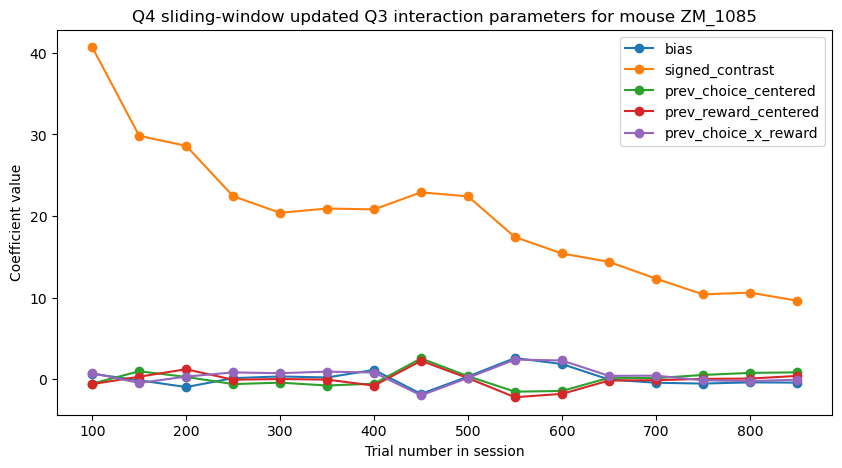

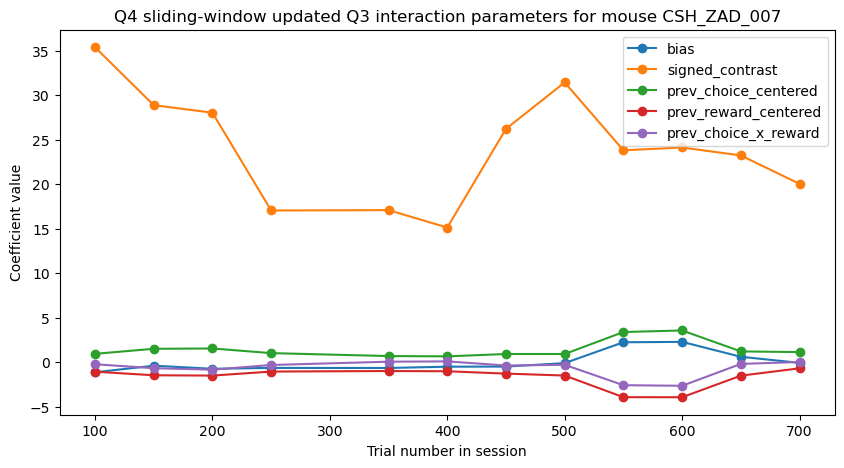

In [32]:
for subject in window_results_table['subject'].unique():

    mouse_table = window_results_table[
        window_results_table['subject'] == subject
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        mouse_table['window_center'],
        mouse_table['bias_est'],
        marker='o',
        label='bias'
    )

    for feature_name in q4_feature_columns:
        est_column = f'{feature_name}_est'
        if est_column in mouse_table.columns:
            plt.plot(
                mouse_table['window_center'],
                mouse_table[est_column],
                marker='o',
                label=feature_name
            )

    plt.xlabel('Trial number in session')
    plt.ylabel('Coefficient value')
    plt.title(f'Q4 sliding-window updated Q3 interaction parameters for mouse {subject}')
    plt.legend()
    plt.show()


Cochran-style heterogeneity statistic Q делает одну конкретную вещь:

- собирает различия между коэффициентами из всех окон в одно число и проверяет, слишком ли эти различия большие, чтобы объяснить их обычной статистической ошибкой.

- Пусть в каждом окне получен коэффициент: βi и его стандартная ошибка = SEi 

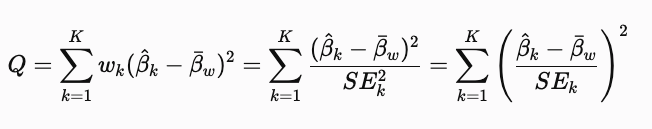

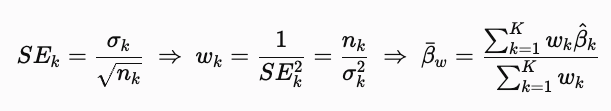

In [33]:
# 5. Test whether coefficients change across windows.
# This is a Cochran-style weighted test.
# p_value < 0.05 means the parameter changed significantly over time.
stationarity_results = []

for (subject, session), df_win in window_results.items():
    
    for name in PARAM_NAMES:          #contrast, previous_choice, previous_reward.
        est = df_win[f'{name}_est'].values #get оценки выбранного коэффициента из всех окон.
        se = df_win[f'{name}_se'].values     #берёт standard error этого коэффициента для каждого окна.

        weights = 1 / se**2     #calculate the weights. Чем меньше ошибка, тем больше доверие к оценке. 
        mean_est = np.sum(weights * est) / np.sum(weights)  #считает общий взвешенный средний коэффициент

        Q = np.sum(weights * (est - mean_est) ** 2)    #измеряет, насколько коэффициенты разных окон отличаются от общего среднего
        dof = len(est) - 1           #число степеней свободы K — количество окон.
        p = stats.chi2.sf(Q, dof)    #вычисляет вероятность получить такой большой Q, если коэффициент на самом деле не менялся. p value

        stationarity_results.append({
            'subject': subject,
            'parameter': name,
            'p_value': p,
            'significant_change': p < 0.05
        })


# 6. Final stationarity result table.
# If significant_change is True, that parameter is not stable across the session.
stationarity_table = pd.DataFrame(stationarity_results)
display(stationarity_table)

,subject,parameter,p_value,significant_change
0,ZM_1085,bias,7.698215e-01,False
1,ZM_1085,signed_contrast,1.604951e-07,True
2,ZM_1085,prev_choice_centered,2.286794e-01,False
3,ZM_1085,prev_reward_centered,9.967557e-01,False
4,ZM_1085,prev_choice_x_reward,7.895519e-01,False
5,CSH_ZAD_007,bias,8.578119e-01,False
6,CSH_ZAD_007,signed_contrast,3.373068e-02,True
7,CSH_ZAD_007,prev_choice_centered,9.986855e-01,False
8,CSH_ZAD_007,prev_reward_centered,9.965102e-01,False
9,CSH_ZAD_007,prev_choice_x_reward,9.983773e-01,False


### Null hypothesis

$$
H_0:\ \beta_1=\beta_2=\cdots=\beta_K
$$

**The coefficient is the same across all windows.**
**Коэффициент одинаковый во всех окнах.**

| p-value       | Interpretation                                                                                                                                                         |
| ------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| $p < 0.05$    | **Reject $H_0$:** the coefficient changed over time. <br> **Отклоняем $H_0$:** коэффициент менялся со временем.                                                        |
| $p \geq 0.05$ | **Fail to reject $H_0$:** there is not enough evidence that the coefficient changed. <br> **Не отклоняем $H_0$:** недостаточно доказательств, что коэффициент менялся. |


In [34]:
import pickle
import types
from pathlib import Path

Path("notebook_outputs").mkdir(exist_ok=True)

workspace = {}

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue
    if name in ["In", "Out", "exit", "quit", "get_ipython"]:
        continue
    if isinstance(value, types.ModuleType):
        continue
    if callable(value):
        continue

    try:
        pickle.dumps(value)
        workspace[name] = value
    except Exception:
        pass

with open("notebook_outputs/q4_workspace.pkl", "wb") as f:
    pickle.dump(workspace, f)

print("saved q4")

saved q4
